# Single Match Analysis - Final Match




## 0. Setup - Imports and Configuration

In [406]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, print_top_predictions, get_top_indices, create_top_sequences, visualize_top_sequences
from src.analysis.visualization import plot_possession_actions
from src.data.data_loader import load_socceraction_match
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence_preprocessor import SequencePreprocessor, PreprocessingMode
from src.ml.preprocessing.xthreat import get_default_xt_model


In [407]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [408]:
match_id = 3943043
selected_match, selected_events = load_socceraction_match("data/statsbomb/data", 55, 282, match_id)

print(f"Loaded match: {game_summary(selected_match)} with {len(selected_events)} events")

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loaded match: Spain 2 : 1 England (Final) [14.07.2024] with 3312 events


## 2. Load Trained Model

In [409]:
# Load the best trained model
MODEL_TYPE = 'attention_lstm'  # Change to 'transformer' if using the transformer model
MODEL_DIR = 'models/attention_lstm_baseline'

model = load_model(MODEL_TYPE, MODEL_DIR)
print(f"Model type: {MODEL_TYPE}")


Model type: attention_lstm


In [410]:
# Display model architecture
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 8, 46)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 8, 46)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_4 (Masking) │ (None, 8, 46)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_4 (Any)         │ (None, 8)         │          0 │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 8, 128)    │     56,832 │ masking_4[0][0],  │
│ (Bidirectional)     │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 8, 128)    │          0 │ bidirectional_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 8, 64)     │     49,408 │ dropout_10[0][0], │
│                     │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 8, 64)     │          0 │ lstm_8[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ [(None, 64),      │         72 │ dropout_11[0][0], │
│ (AttentionLayer)    │ (None, 8)]        │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      4,160 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_7[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         65 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 331,613 (1.27 MB)

 Trainable params: 110,537 (431.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 221,076 (863.58 KB)

## 3. Preprocess Data for Analysis

In [411]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p = preprocessor.process_match(match_id, selected_match, selected_events, mode=PreprocessingMode.TRAINING)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: training)
 → Generated 1141 sequences, 1141 labels for match 3943043
Validation set preprocessed: 1141 sequences


In [412]:
X.shape

(1141, 8, 46)

In [413]:
p.shape

(1141,)

In [414]:
p[0:2]

array([   game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name      player_name  possession type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
       0  3943043  152820f0-6ca9-4df3-943b-a67d568ff472          1         0.340      768    99174.0  52.45625  34.0425   22.18125  35.0625        0          1            5          0   England    Kobbie Mainoo           2      Pass  2.529454           False         False  0.0                 768              England  0.010165 -30.2750   1.020  30.292178  3.107914      0.000                0
       1  3943043  9c107df3-a3c8-4ad5-bc35-00214087a105          1         2.870      768     3468.0  22.18125  35.0625   25.06875  41.1825       21          1            0          1   England  Jordan Pickford

## 4. Analysis


#### Make predictions on match sequences

In [415]:
predictions = model.predict(X, batch_size=32, verbose=0)
predictions

{'value': array([[0.0898104 ],
        [0.01294477],
        [0.01519045],
        ...,
        [0.02552807],
        [0.0120499 ],
        [0.0266482 ]], dtype=float32),
 'attention_weights': array([[0.45091867, 0.32293698, 0.22614434, ..., 0.        , 0.        ,
         0.        ],
        [0.10259292, 0.08913934, 0.08416367, ..., 0.13983098, 0.21394177,
         0.19533612],
        [0.1181431 , 0.09650478, 0.08991733, ..., 0.12040257, 0.187871  ,
         0.20140438],
        ...,
        [0.26728165, 0.2604838 , 0.23783608, ..., 0.        , 0.        ,
         0.        ],
        [0.16925032, 0.14120394, 0.13312286, ..., 0.2585936 , 0.        ,
         0.        ],
        [0.31509095, 0.27140814, 0.21132189, ..., 0.        , 0.        ,
         0.        ]], dtype=float32)}

#### Predictions

In [416]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 1141
Sum of all predicted values: 35.569
Has attention weights: True


#### LSTM Attention Weights and Predicted Values

#### Get top 8 sequences by predicted value

In [417]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p, None, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Possession id =       game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name             player_name  possession type_name  duration  under_pressure  counterpress        xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
1836  3943043  77013fec-81ba-420d-855d-a0fb28419ed6          2      2448.556      772     6655.0  43.09375  28.0925   45.98125  28.4325       21          1            0       1836     Spain        Fabián Ruiz Peña         136     Carry  0.838384            True         False  0.000000                 772                Spain  0.014846   2.8875   0.340   2.907448  0.117209      0.993                0
1837  3943043  f06a66c5-ac21-4f2f-ad39-b144ab8e1418          2      2449.394      772     6655.0  45.98125  28.4325   55.43125

#### Top possessions information

In [418]:
sorted_indices = get_top_indices(predicted_values)
top_indices = sorted_indices[:50]
top_indices

array([1132,  740, 1137,  196,   67, 1007, 1136,  569,  197,  568, 1114,
        892, 1006,  883,  888,   66,  268,   64,   63,  891, 1046,  943,
        181,  944, 1131,  191,  488,  192, 1047,  573,  567,  321, 1048,
        743,  332,  601,  331,  744,  741,  330,  742, 1005,  746,  739,
        620,  745,  619,  224,  879, 1135])

#### Save top possessions dataframe

In [419]:
p[2]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
4,3943043,987a3f1e-4dc4-4833-8896-5513e35c3fc5,1,35.6580,772,22128.0,7.91875,19.4225,7.74375,19.4225,21,1,0,4,Spain,Robin Aime Robert Le Normand,3,Carry,0.620663,False,False,0.0,772,Spain,0.008880,-0.1750,0.000,0.175000,3.141593,1.2180,0
5,3943043,660f4d9e-9ae4-4a8c-9f44-acdbc0a04e8c,1,36.2790,772,22128.0,7.74375,19.4225,17.98125,3.6125,0,1,5,5,Spain,Robin Aime Robert Le Normand,3,Pass,1.390837,False,False,0.0,772,Spain,0.008449,10.2375,-15.810,18.835140,-0.996157,0.6210,0
6,3943043,786c039a-7010-475c-9a75-9bf41b4e5700,1,37.6700,772,5721.0,17.98125,3.6125,24.98125,3.1025,21,1,0,6,Spain,Daniel Carvajal Ramos,3,Carry,1.766383,True,False,0.0,772,Spain,0.008449,7.0000,-0.510,7.018554,-0.072729,1.3910,0
7,3943043,dd8cccdf-05dc-41ca-b617-8812c416d5d2,1,39.4360,772,5721.0,24.98125,3.1025,43.88125,9.8175,0,1,5,7,Spain,Daniel Carvajal Ramos,3,Pass,1.076726,False,False,0.0,772,Spain,0.013845,18.9000,6.715,20.057448,0.341381,1.7660,0
8,3943043,9072242c-b13e-4e85-8578-8cd9a606a614,1,40.5130,772,16532.0,43.88125,9.8175,43.09375,9.4775,21,1,0,8,Spain,Daniel Olmo Carvajal,3,Carry,0.132449,True,False,0.0,772,Spain,0.012147,-0.7875,-0.340,0.857762,-2.734022,1.0770,0
9,3943043,2b4b2e7e-229a-41b6-91cc-c4e3de546443,1,40.6450,772,16532.0,43.09375,9.4775,43.09375,9.4775,19,0,0,9,Spain,Daniel Olmo Carvajal,3,Miscontrol,0.000000,False,False,0.0,772,Spain,0.012147,0.0000,0.000,0.000000,0.000000,0.1320,0
10,3943043,bd7a4187-f3ad-4f5b-a85c-e36ddeff8058,1,41.2615,772,3477.0,43.09375,9.4775,54.11875,11.0075,21,1,0,10,Spain,Álvaro Borja Morata Martín,3,Pass,0.264950,False,False,0.0,772,Spain,0.016118,11.0250,1.530,11.130657,0.137895,0.6165,0
11,3943043,bd7a4187-f3ad-4f5b-a85c-e36ddeff8058,1,41.8780,772,3477.0,54.11875,11.0075,56.91875,11.1775,0,0,5,11,Spain,Álvaro Borja Morata Martín,3,Pass,0.264950,False,False,0.0,772,Spain,0.016118,2.8000,0.170,2.805156,0.060640,0.6165,0


In [420]:
top_possessions_df = create_top_sequences(p, predicted_values, attention_weights, head=50)
top_possessions_df.to_csv(f"{MODEL_DIR}/top_possessions_final_df.csv", index=False)
top_possessions_df.head()

,possession_id,value,attention_weights,game_id,team_id,team_name,period,time_start,time_end,outcome
0,136,0.287626,"[0.16181299, 0.115897626, 0.07775725, 0.066993505, 0.085676916, 0.13874228, 0.1923745, 0.16074486]",3943043,772,Spain,2,5148,5156,Goal
1,92,0.286406,"[0.15371895, 0.112736315, 0.07512363, 0.0643294, 0.08306995, 0.13705836, 0.19672206, 0.17724143]",3943043,772,Spain,2,3287,3299,Shot
2,138,0.283854,"[0.30480784, 0.23322867, 0.14171307, 0.12878574, 0.1914646, 0.0, 0.0, 0.0]",3943043,768,England,2,5352,5357,Shot
3,26,0.270509,"[0.16003418, 0.11623784, 0.078180335, 0.06765338, 0.08841057, 0.14616382, 0.19560394, 0.14771602]",3943043,768,England,1,872,883,Pass
4,9,0.270475,"[0.16390431, 0.11871687, 0.07843228, 0.06811822, 0.08862865, 0.14096746, 0.19487078, 0.14636146]",3943043,772,Spain,1,244,258,Pass


#### Visualize top 8 possessions on the pitch

Processed sequence index: 1132 with predicted value: 0.288
Processed sequence index: 740 with predicted value: 0.286
Processed sequence index: 1137 with predicted value: 0.284
Processed sequence index: 196 with predicted value: 0.271
Processed sequence index: 67 with predicted value: 0.270
Processed sequence index: 1007 with predicted value: 0.270
Processed sequence index: 1136 with predicted value: 0.269
Processed sequence index: 569 with predicted value: 0.268


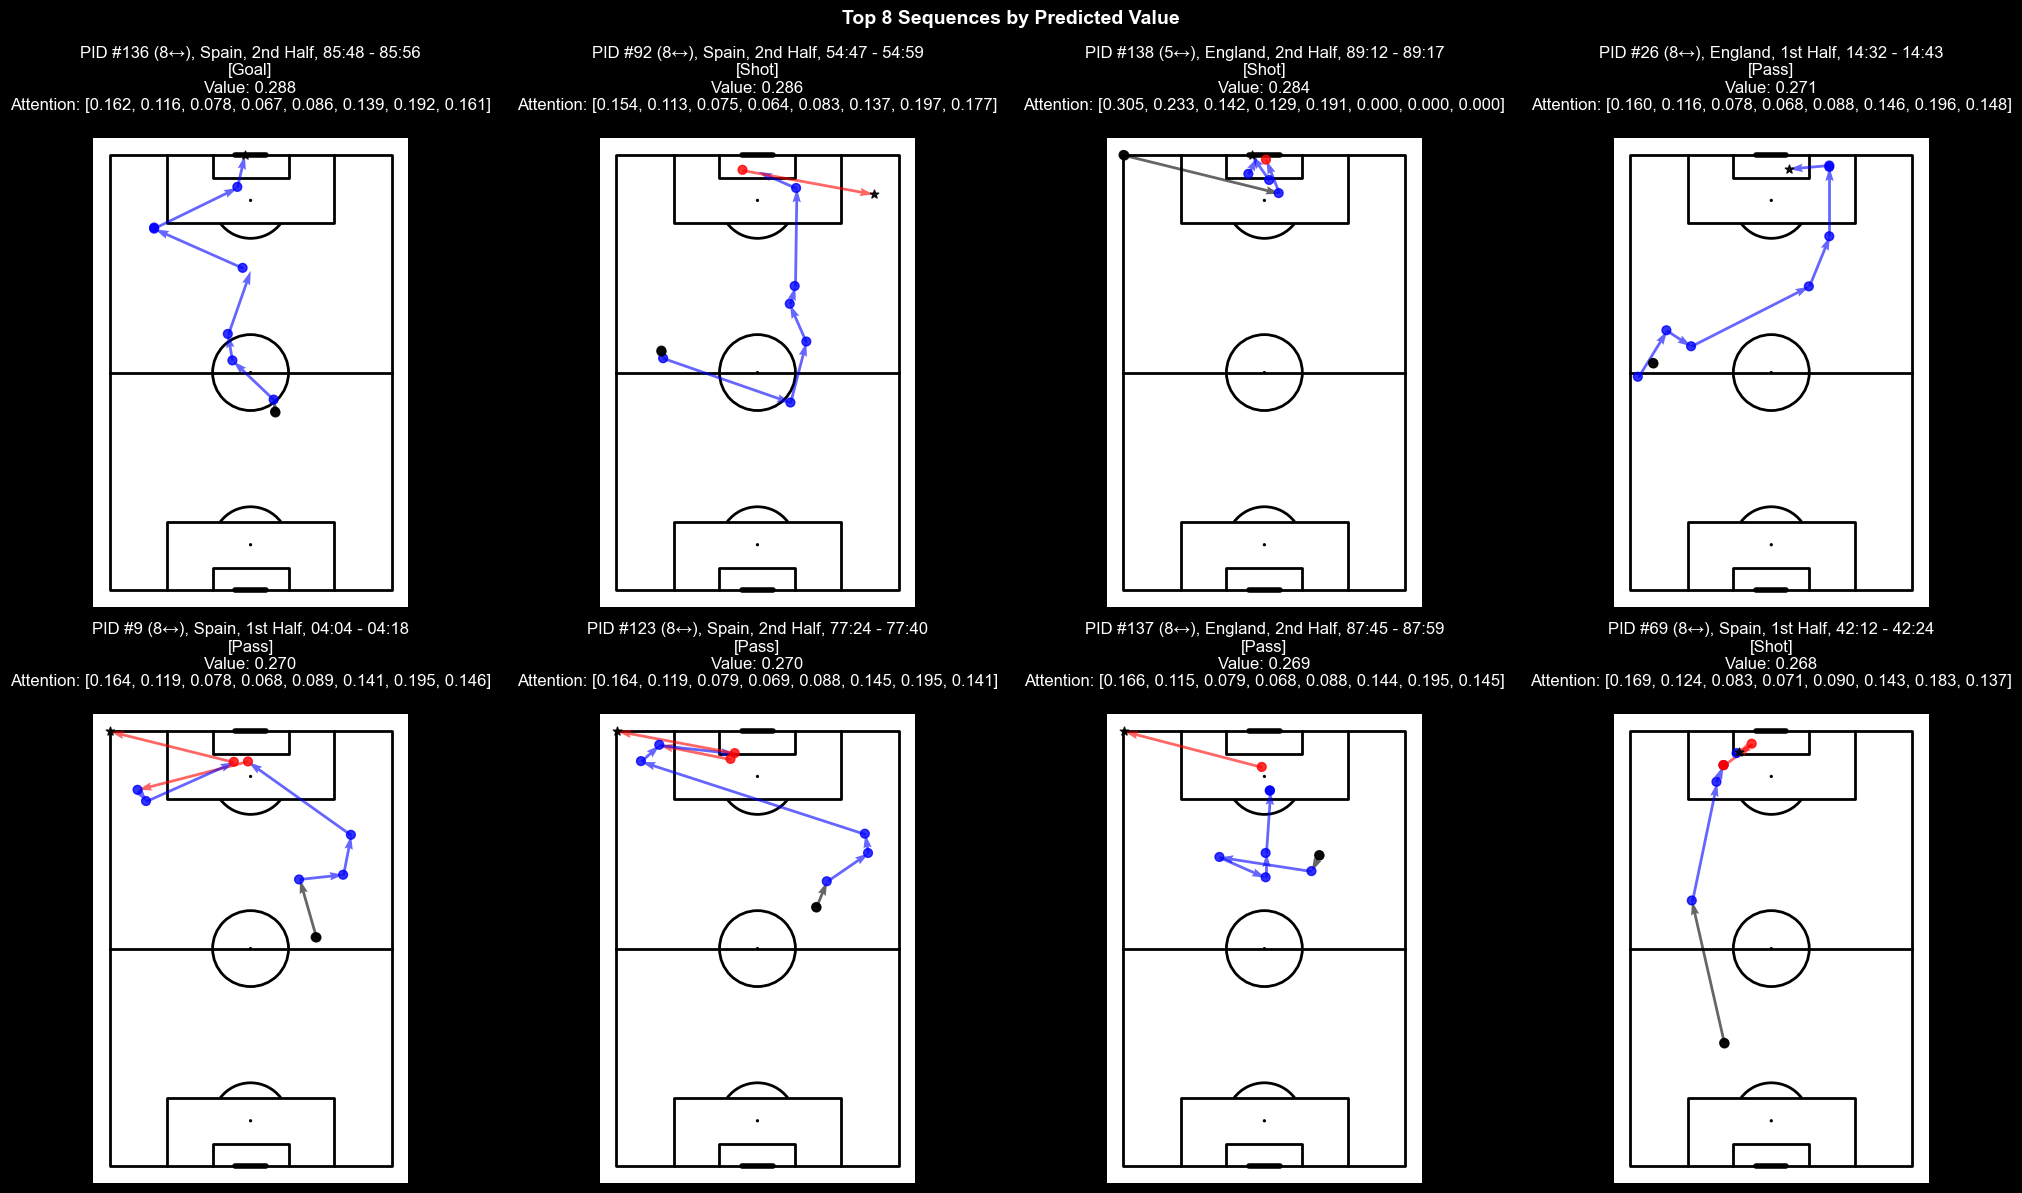

In [421]:
visualize_top_sequences(p, predicted_values, attention_weights, 8, cols=4)
plt.savefig(f"{MODEL_DIR}/top_possessions_final.png", dpi=300)


## 5. Additional Analysis

#### Analyse specific possession by index

In [422]:
top_indices = get_top_indices(predicted_values)

Processed sequence index: 78 with predicted value: 0.027


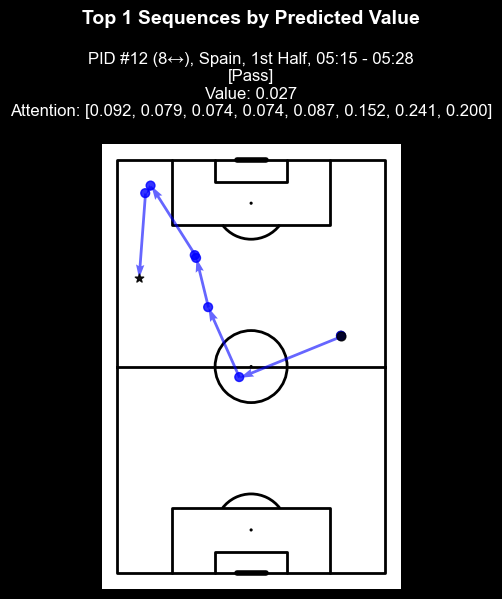

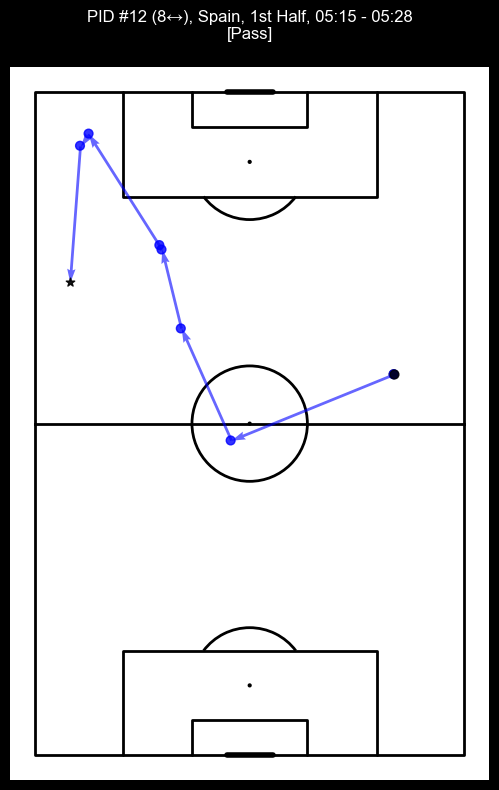

In [423]:
possession_id = 78
visualize_top_sequences(p, predicted_values, attention_weights, indices=np.array([possession_id]))
plot_possession_actions(p[possession_id])
None

#### Find sequences with length less then SEQUENCE_LENGTH

In [424]:
p[0]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
0,3943043,152820f0-6ca9-4df3-943b-a67d568ff472,1,0.340,768,99174.0,52.45625,34.0425,22.18125,35.0625,0,1,5,0,England,Kobbie Mainoo,2,Pass,2.529454,False,False,0.0,768,England,0.010165,-30.2750,1.020,30.292178,3.107914,0.000,0
1,3943043,9c107df3-a3c8-4ad5-bc35-00214087a105,1,2.870,768,3468.0,22.18125,35.0625,25.06875,41.1825,21,1,0,1,England,Jordan Pickford,2,Carry,1.872089,False,False,0.0,768,England,0.010165,2.8875,6.120,6.766983,1.129951,2.530,0
2,3943043,237201b8-aef8-4823-b282-e82875795c07,1,4.742,768,3468.0,25.06875,41.1825,104.95625,10.4975,0,0,4,2,England,Jordan Pickford,2,Pass,5.137795,False,False,0.0,768,England,0.046477,79.8875,-30.685,85.577929,-0.366727,1.872,0


In [425]:
short_sequence_ids = np.array([i for i, df in enumerate(p) if len(df) < config.SEQUENCE_LENGTH])
print(f"IDs of short sequences: {short_sequence_ids}")

IDs of short sequences: [   0   19   68   69  144  149  181  193  241  269  317  318  322  323
  324  333  389  398  399  456  570  571  573  574  575  602  637  642
  753  877  880  881  884  885  886  897  919  920  950 1008 1041 1073
 1074 1137 1138 1139 1140]


#### Create X_short_sequences and p_short_sequences

In [426]:
X_short_sequences = X[short_sequence_ids]
p_short_sequences = p[short_sequence_ids]

print(f"X_short_sequences shape: {X_short_sequences.shape}")
print(f"Number of short sequences: {len(p_short_sequences)}")

X_short_sequences shape: (47, 8, 46)
Number of short sequences: 47


#### Make predictions on short sequences

In [427]:
predictions_short = model.predict(X_short_sequences, batch_size=32, verbose=0)
predicted_values_short, attention_weights_short = normalize_predictions(predictions_short)

print(f"Total short sequences analyzed: {len(predicted_values_short)}")
print(f"Sum of predicted values: {predicted_values_short.sum():.3f}")
print(f"Has attention weights: {attention_weights_short is not None}")

Total short sequences analyzed: 47
Sum of predicted values: 2.039
Has attention weights: True


#### Visualize short sequences

Processed sequence index: 43 with predicted value: 0.284
Processed sequence index: 6 with predicted value: 0.217
Processed sequence index: 22 with predicted value: 0.188
Processed sequence index: 39 with predicted value: 0.106
Processed sequence index: 37 with predicted value: 0.091
Processed sequence index: 0 with predicted value: 0.090
Processed sequence index: 32 with predicted value: 0.090
Processed sequence index: 38 with predicted value: 0.085


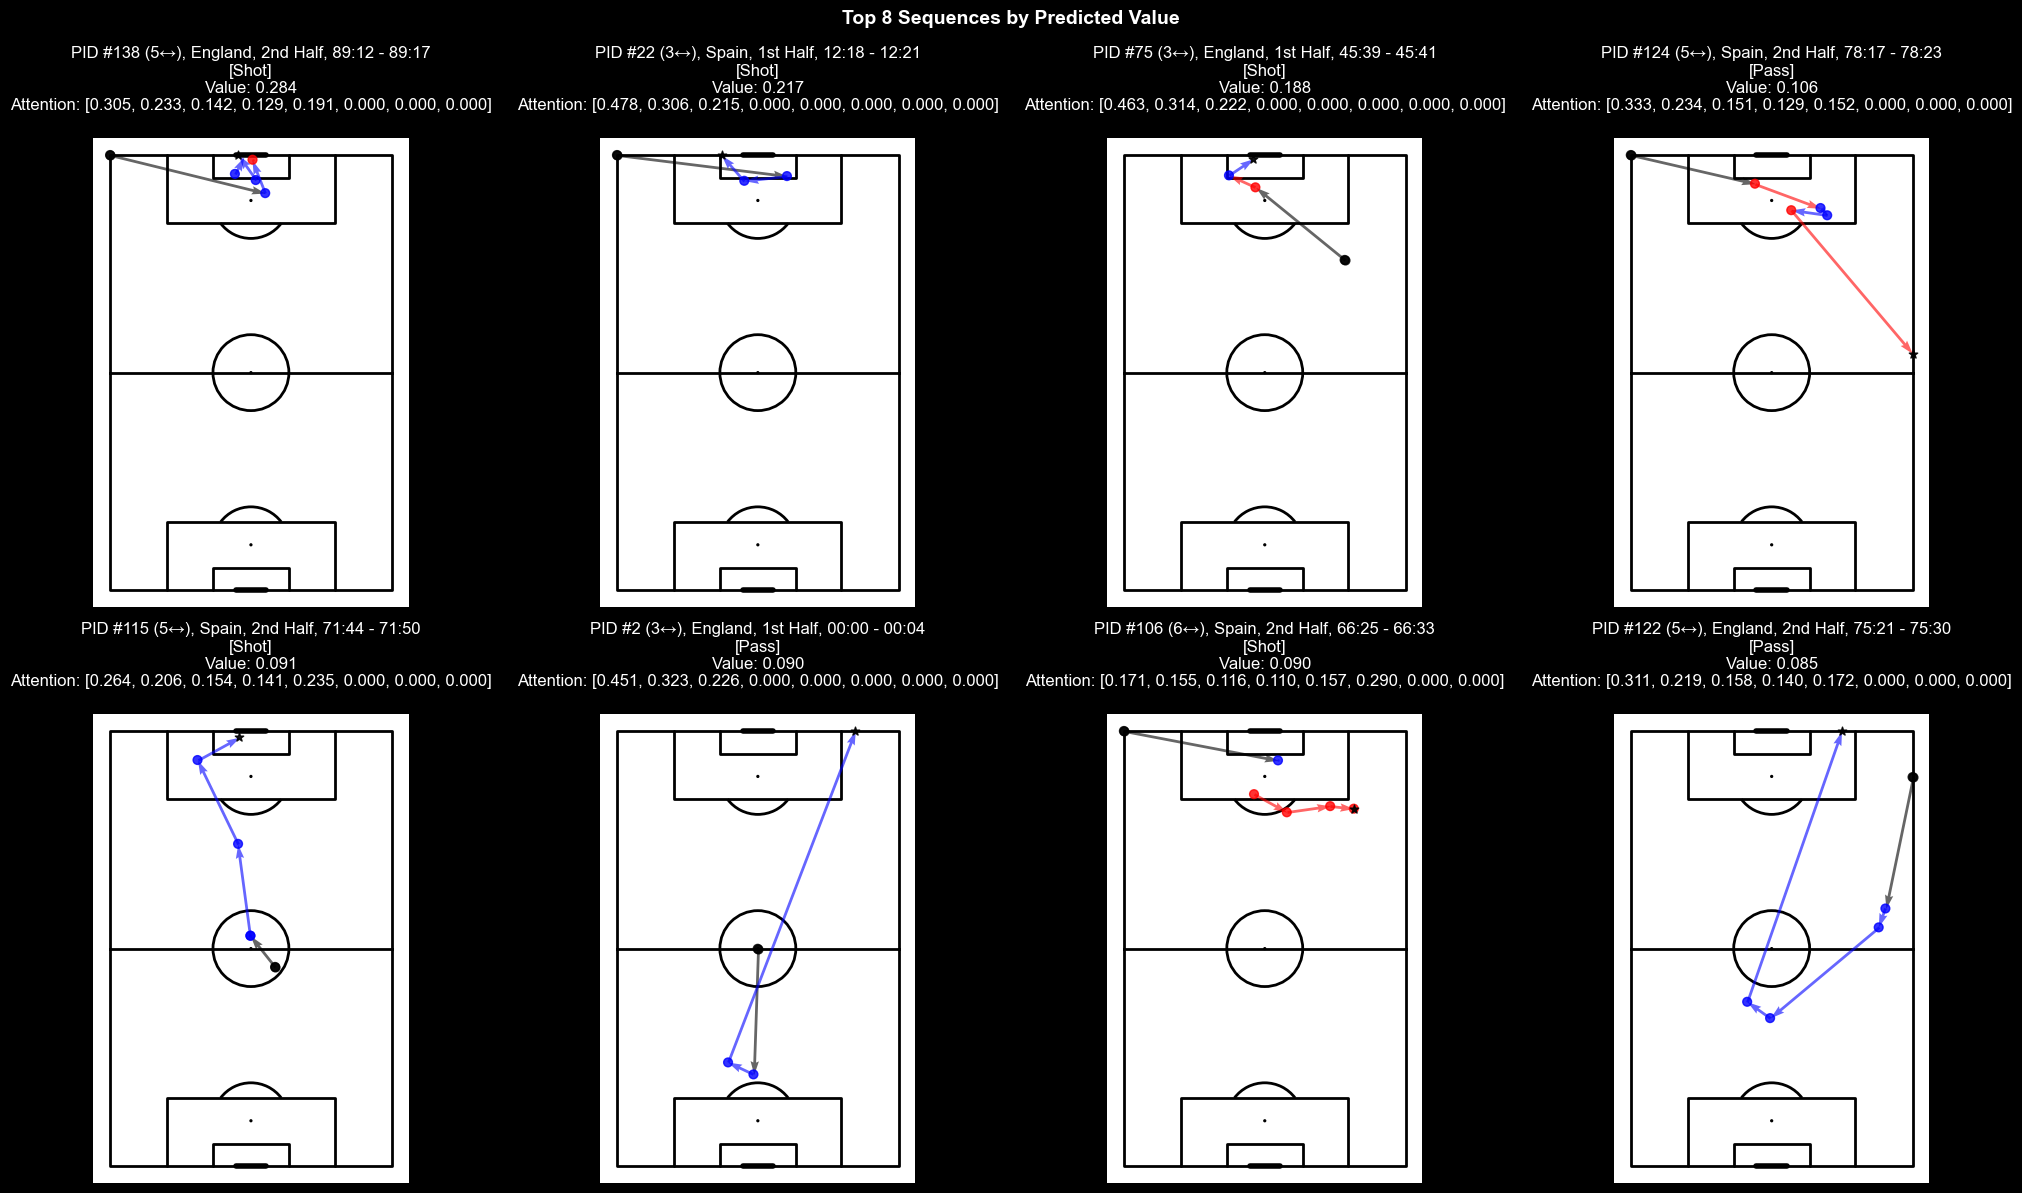

In [428]:
visualize_top_sequences(p_short_sequences, predicted_values_short, attention_weights_short, 8, cols=4)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_short_sequences.png", dpi=300)


#### Get top indices from short sequences

In [429]:
top_indices_short = get_top_indices(predicted_values_short)
top_indices_short

array([43,  6, 22, 39, 37,  0, 32, 38, 35, 13,  2, 25, 23, 33, 10, 42, 46,
       19, 44, 31, 17, 26, 14, 36,  9,  7, 15, 40, 30, 27, 11, 29,  5, 20,
        8,  3, 24, 18, 45, 21, 28,  4, 12, 34, 41, 16,  1])

Processed sequence index: 35 with predicted value: 0.080


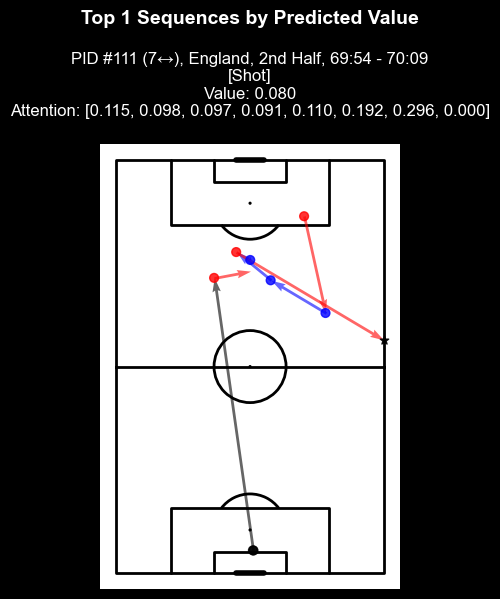

In [430]:
visualize_top_sequences(p_short_sequences, predicted_values_short, attention_weights_short, indices=np.array([35]))
None

In [431]:
p_short_sequences[35]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
1466,3943043,ee3965c5-7ea2-4405-9d33-3bf4bcd89538,2,1494.999,768,3468.0,5.81875,33.2775,75.03125,43.1375,22,0,4,1466,England,Jordan Pickford,111,Pass,3.873401,False,False,0.000000,768,England,0.009411,69.2125,9.860,69.911299,0.141508,0.000,0
1467,3943043,2b56f4f6-ba40-43c1-b08b-729e47adc9da,2,1498.872,772,5721.0,75.03125,43.1375,76.78125,33.8725,0,0,1,1467,Spain,Daniel Carvajal Ramos,111,Pass,0.817431,False,False,0.000000,768,England,0.023851,1.7500,-9.265,9.428824,-1.384113,3.873,1
1468,3943043,be6417cc-b3ec-4a67-a4b2-e6648b14566d,2,1499.964,768,4760.0,79.58125,33.9575,80.63125,34.0425,11,0,5,1468,England,Ollie Watkins,111,Shot,0.018527,True,False,0.074709,768,England,0.035113,1.0500,0.085,1.053435,0.080776,1.092,0
1469,3943043,785459cb-64aa-4d0b-87e0-b69ae592c3b2,2,1502.188,772,4353.0,90.69375,20.2725,66.10625,14.8325,18,1,4,1469,Spain,Aymeric Laporte,111,Clearance,0.000000,True,False,0.000000,768,England,0.054911,-24.5875,-5.440,25.182112,-2.923850,2.224,1
1470,3943043,55208b6e-d847-4a73-93cd-8bf0e9d61bef,2,1505.318,768,30714.0,66.10625,14.8325,74.41875,28.7725,21,1,0,1470,England,Jude Bellingham,111,Carry,3.429030,True,False,0.000000,768,England,0.023851,8.3125,13.940,16.230257,1.033098,3.130,0
1471,3943043,540e7ddf-44b3-435f-a4fe-5dbdf522d835,2,1508.747,768,30714.0,74.41875,28.7725,81.59375,37.5275,0,0,5,1471,England,Jude Bellingham,111,Pass,1.071324,True,False,0.000000,768,England,0.035113,7.1750,8.755,11.319481,0.884259,3.429,0
1472,3943043,166eb4c8-d6f5-4c14-a8d6-c132cf2f19a4,2,1509.818,772,22128.0,81.59375,37.5275,59.28125,0.0425,0,0,5,1472,Spain,Robin Aime Robert Le Normand,111,Pass,2.783475,False,False,0.000000,768,England,0.014736,-22.3125,-37.485,43.623077,-2.107707,1.071,1


In [432]:
X_short_sequences[35]

array([[ 5.54166660e-02,  4.89374995e-01,  7.14583337e-01,
         6.34374976e-01,  6.65821910e-01,  1.41035855e-01,
         9.90004480e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 7.14583337e-01,  6.34374976e-01,  7.31249988e-01,
         4.98124987e-01,  8.97

In [433]:
attention_weights_short[35]

array([0.11525795, 0.09808625, 0.09728769, 0.09148779, 0.10958377,
       0.19233371, 0.29596284, 0.        ], dtype=float32)